# Modelling and evaluation: Logistic Regression - multiclass classification

Logistic regression is a supervised learning model that can predict lables based on labelled training data. 
As there are three possible outcomes standard, budget and luxury, multiclass classificaion is used.

Supervised Machine Learning follows four steps: 
1. choose a class of model
2. Choose model hyperparameters
3. Fit the model to the training data
4. use the model to predict labels for new data

# 1. Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import joblib

# 2. Import and Explore Data

The dataset is loaded and the first two columns are dropped below as they are duplicate index columns and have no analytical value. The dataset includes 1925 irish rental property listings and after removing the two index columns the dataset is reduced to 15 columns which all either describe the propertt or the economic context of its county

The target variable, Price_Category has three classes, Standard, Budget and Luxury. Standard is the largest with 962 listings and budget and luxury have 482 and 481, respectively.

In [2]:
df = pd.read_csv('Data_with_class.csv')

In [3]:
print('Dataset Shape: ', df.shape)
df.head()

Dataset Shape:  (1925, 17)


,Unnamed: 0.1,Unnamed: 0,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Average_Value_County,Rent_To_Land_Ratio,Average_Value_Bedroom_Count,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,0,0,Standard,Four plus bed,Carlow,1397.92,17417,61968,976.857368,0.080262,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
1,1,1,Standard,Four plus bed,Carlow,1323.98,17417,61968,976.857368,0.076017,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
2,2,2,Standard,All bedrooms,Carlow,1060.03,17417,61968,976.857368,0.060862,1029.973333,86.53,147.83,25.62,33.55,7.19,53953
3,3,3,Standard,Three bed,Carlow,1028.83,17417,61968,976.857368,0.059070,1002.910000,86.53,147.83,25.62,33.55,7.19,53953
4,4,4,Standard,All bedrooms,Carlow,1017.06,17417,61968,976.857368,0.058395,1029.973333,86.53,147.83,25.62,33.55,7.19,53953


In [4]:
#Drop duplicate columns
df = df.iloc[:, 2:]
print('Dataset Shape: ', df.shape)
df.head()

Dataset Shape:  (1925, 15)


,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Average_Value_County,Rent_To_Land_Ratio,Average_Value_Bedroom_Count,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,Standard,Four plus bed,Carlow,1397.92,17417,61968,976.857368,0.080262,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
1,Standard,Four plus bed,Carlow,1323.98,17417,61968,976.857368,0.076017,1360.950000,86.53,147.83,25.62,33.55,7.19,53953
2,Standard,All bedrooms,Carlow,1060.03,17417,61968,976.857368,0.060862,1029.973333,86.53,147.83,25.62,33.55,7.19,53953
3,Standard,Three bed,Carlow,1028.83,17417,61968,976.857368,0.059070,1002.910000,86.53,147.83,25.62,33.55,7.19,53953
4,Standard,All bedrooms,Carlow,1017.06,17417,61968,976.857368,0.058395,1029.973333,86.53,147.83,25.62,33.55,7.19,53953


### Target Class Distribution
Our target variable `Price_category` has three classes and these classes are distributed as follows:

| Price_Category | Count | % of listings |
|---|---|---|
| Standard | 962 | 50% |
| Budget | 482 | 25% |
| Luxury | 481 | 25% |

As evident there is a class imbalance and despite it only being a mild class imbalance it still justrifies the use of `class_weight='balanced'` in the model.

This is to prevent the model defaulting to the majority class.

In [5]:
print(df['Price_Category'].value_counts())

Price_Category
Standard    962
Budget      482
Luxury      481
Name: count, dtype: int64


# 3. Feature Selection and Pre-processing

Before training the model we followed the following pre-processing steps

**One-Hot Encoding**
Each of the counties in the dataset is converted into a binary column in order for county to be in the model which is a key irish local context feature. `pd.get_dummies()` creates binary columns which is critical as pricing varies across counties. 

**Label Encoding for no. of bedrooms**
The bedroom categories were converted to numeric values using `LabelEncoder` so that the model can proccess them. 

**Excluding Features**
Four tax receipt columns are removed following their correlation analysis in our EDA section which identified extremely high correlations between these varibales and population of county

Including them would have caused multicollinearity in Logistic Regression. 
The columns removed were:
* vat_internal_€m
* self_employed_income_tax_€m
* corporation_tax_€m
* capital_gains_tax_€m

Two other features were also excluded as they directly encode the price tier thresholds used to create the label
* Rent_Price
* Rent_To_Land_Ratio
By dropping these features the model is forced to use information that would be known only before the rent price is set, giving the model a more honest accuracy


In [6]:
# One-hot encode county to keep irish local context feature
df = pd.get_dummies(df, columns=['County'])

In [7]:
# Label encode no. of bedrooms
le_bedrooms = LabelEncoder()
df['Number of Bedrooms']=le_bedrooms.fit_transform(df['Number of Bedrooms'])

In [8]:
# Drop highly correlated tax columns and features which may cause data leakage
df=df.drop(columns=[
    'vat_internal_€m',
    'self_employed_income_tax_€m',
    'corporation_tax_€m',
    'capital_gains_tax_€m',
    'Rent_Price',
    'Rent_To_Land_Ratio',
])
print(df.shape)

(1925, 34)


In [9]:
# brief view of dataset after pre proccessing and feature selection
df.head()

,Price_Category,Number of Bedrooms,Land_Price,Population of County,Average_Value_County,Average_Value_Bedroom_Count,paye_income_tax_and_usc_€m,Net_Income,County_Carlow,County_Cavan,...,County_Meath,County_Monaghan,County_Offaly,County_Roscommon,County_Sligo,County_Tipperary,County_Waterford,County_Westmeath,County_Wexford,County_Wicklow
0,Standard,3,17417,61968,976.857368,1360.950000,147.83,53953,True,False,...,False,False,False,False,False,False,False,False,False,False
1,Standard,3,17417,61968,976.857368,1360.950000,147.83,53953,True,False,...,False,False,False,False,False,False,False,False,False,False
2,Standard,2,17417,61968,976.857368,1029.973333,147.83,53953,True,False,...,False,False,False,False,False,False,False,False,False,False
3,Standard,5,17417,61968,976.857368,1002.910000,147.83,53953,True,False,...,False,False,False,False,False,False,False,False,False,False
4,Standard,2,17417,61968,976.857368,1029.973333,147.83,53953,True,False,...,False,False,False,False,False,False,False,False,False,False


# 4. Target Vector and Feature Matrix

The data is arranged into a feature matric X which contains all predictor variables and y includes the target varibale - Price_Category

In [10]:
y=df['Price_Category']
X=df.drop(columns=['Price_Category'])

In [11]:
X=X.reindex(sorted(X.columns), axis = 1)

In [12]:
print(list(X.columns))

['Average_Value_Bedroom_Count', 'Average_Value_County', 'County_Carlow', 'County_Cavan', 'County_Clare', 'County_Cork', 'County_Donegal', 'County_Dublin', 'County_Galway', 'County_Kerry', 'County_Kildare', 'County_Kilkenny', 'County_Laois', 'County_Leitrim', 'County_Limerick', 'County_Longford', 'County_Louth', 'County_Mayo', 'County_Meath', 'County_Monaghan', 'County_Offaly', 'County_Roscommon', 'County_Sligo', 'County_Tipperary', 'County_Waterford', 'County_Westmeath', 'County_Wexford', 'County_Wicklow', 'Land_Price', 'Net_Income', 'Number of Bedrooms', 'Population of County', 'paye_income_tax_and_usc_€m']


In [13]:
le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [14]:

X.shape

(1925, 33)

In [15]:
y.shape

(1925,)

# 5. Train/Test split and Scaling

The dataset is split into 75% training data and 25% test data through the use of `train_test_split`.

`stratify=y` ensures that the proportions of Budget, Standard and Luxury are preserved in both sets, which is important to this model given Standard has double the amount of records as either Budget or Luxury. 

To prepare the data for Logistic Regression, the features are standardised using `StandardScaler`.

Wihtout scaling, large scale variables would dominate smaller scale variables .

In [16]:
# 75/25 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
                                                    random_state=0, stratify=y)
print('Train shape: ', X_train.shape)
print('Test shape: ', X_test.shape)

Train shape:  (1443, 33)
Test shape:  (482, 33)


In [17]:
# Scale features 
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(X_train)

[[-1.22586905 -1.21617481 -0.10249001 ... -1.3114761  -0.95176923
  -0.82803986]
 [-1.25329806 -1.18291153 -0.10249001 ... -1.3114761  -0.79005414
  -0.80040817]
 [ 0.78538286  1.27627456 -0.10249001 ... -1.3114761   1.34700952
   1.37381419]
 ...
 [ 0.06923641  0.04293923 -0.10249001 ... -0.3539957  -0.65775008
  -0.68759421]
 [-0.30878243 -0.44424722 -0.10249001 ... -0.3539957  -0.7210839
  -0.71522915]
 [-0.95414854 -0.97107761 -0.10249001 ...  1.5609651  -0.95187026
  -0.81336307]]


# 6. Fit the Logistic Regression Model
**Hyperparameters**
* `max_iter=3000` as the default number of iterations was insufficient for our dataste
* `class_weight=balanced` is used as the dataset has a class imbalance where there are around twice as many standard rows as there are budget or luxury. This prevents the model for favouring the majority class

In [18]:
classifier = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=0)

In [19]:
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [20]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[2 2]
 [2 2]
 [1 2]
 [0 0]
 [2 0]
 [0 2]
 [0 0]
 [0 0]
 [2 2]
 [1 1]
 [2 2]
 [1 1]
 [0 0]
 [1 2]
 [2 2]
 [1 2]
 [2 2]
 [2 2]
 [2 2]
 [1 1]
 [0 0]
 [0 2]
 [2 0]
 [2 2]
 [0 0]
 [2 1]
 [2 2]
 [2 2]
 [0 0]
 [2 2]
 [2 2]
 [1 1]
 [0 0]
 [2 2]
 [2 2]
 [1 1]
 [2 2]
 [2 2]
 [0 2]
 [1 1]
 [2 2]
 [2 2]
 [2 2]
 [0 0]
 [2 1]
 [0 0]
 [2 0]
 [1 2]
 [1 1]
 [0 0]
 [0 0]
 [2 2]
 [0 2]
 [2 2]
 [1 1]
 [2 2]
 [1 1]
 [1 1]
 [2 2]
 [1 1]
 [1 1]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 2]
 [0 2]
 [2 2]
 [2 2]
 [0 0]
 [2 2]
 [1 2]
 [2 2]
 [0 0]
 [2 1]
 [2 2]
 [2 2]
 [0 0]
 [2 2]
 [2 1]
 [0 0]
 [0 0]
 [0 2]
 [1 1]
 [1 1]
 [1 1]
 [0 2]
 [2 2]
 [2 2]
 [0 0]
 [1 1]
 [2 2]
 [2 2]
 [0 2]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [2 0]
 [0 0]
 [1 2]
 [2 2]
 [0 0]
 [1 1]
 [1 2]
 [2 2]
 [2 2]
 [0 0]
 [2 2]
 [2 2]
 [1 1]
 [2 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [2 2]
 [1 1]
 [2 2]
 [0 0]
 [0 0]
 [0 2]
 [0 2]
 [1 1]
 [2 2]
 [0 0]
 [2 0]
 [1 1]
 [0 0]
 [1 1]
 [2 2]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [2 2]
 [0 2]
 [1 1]
 [2 1]
 [0 0]
 [2 2]
 [0 2]
 [0 2]

In [21]:
#Export Model 
model_filename = 'Logistic_Regression_Classifier_model_final.pkl'
scaler_filename = 'Logistic_Regression_Scaler_final.pkl'

joblib.dump(classifier, model_filename)
joblib.dump(sc, scaler_filename)

print(f"Model Save To File: " + model_filename)
print(f"Scaler Saved to File: " + scaler_filename)

Model Save To File: Logistic_Regression_Classifier_model_final.pkl
Scaler Saved to File: Logistic_Regression_Scaler_final.pkl


# 7. Evaluation

## 7.1 Model Accuracy Score
The model achieves a test accuracy of 78%

This is a strong result considering that `Rent_Price`, which would be the most direct indicator of a property's tier, was deliberately excluded to prevent data leakage. 

The model is predicting tier level entirely from county-level economic features, land price, property values, and bedroom type, which are all available before any rental valuation is done.

In [22]:
print('Accuracy: ', accuracy_score(y_test, y_pred))

Accuracy:  0.7800829875518672


## 7.2 Confusion Matrix 
The confusion matrix shows how many properties were correctly predicted per tier and where misclassifications occured. 

The values which do not appear on the diaganol line are errors

The y axis shows the the actual tier and the x axis shows the preidicted tier

In [23]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: ')
print(cm)

Confusion Matrix: 
[[107   0  14]
 [  0 107  13]
 [ 46  33 162]]


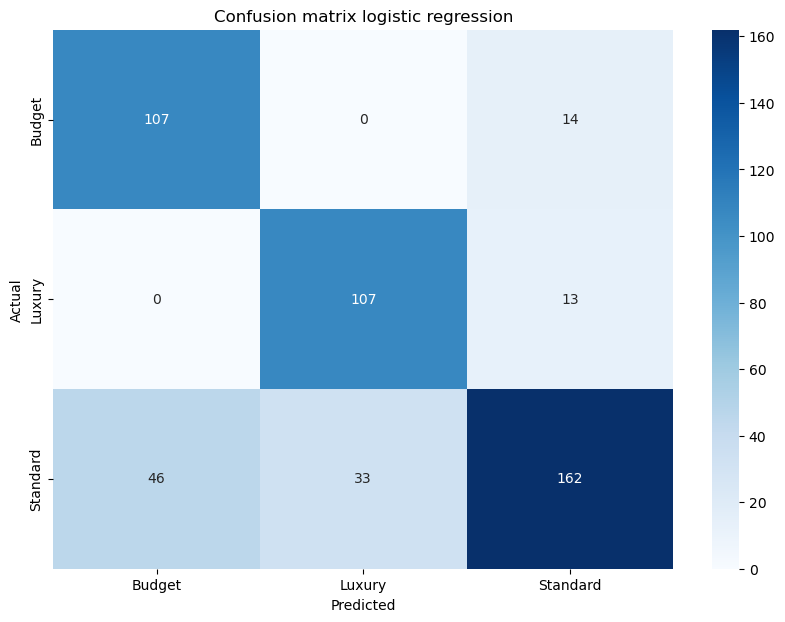

In [24]:
labels = ['Budget', 'Luxury', 'Standard']
plt.figure(figsize =(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
           cmap='Blues')
plt.title('Confusion matrix logistic regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7.3 Classification Report 
Precision, recall and f1-score all give a view of perfomance per class



| Tier | Precision | Recall | f1-score | support |
|---|---|---| --- | --- |
| Budget | 0.70 | 0.88 | 0.78 | 121 |
| Luxury | 0.76 | 0.89 | 0.82 | 120 |
| Standard | 0.86 | 0.67 | 0.75 | 241 |

**Luxury**: This is the best performing class with the highest f1-score and recall score of 0.82 and 0.89 respectivey. The model correctly identified 107 of 120 luxury properties with all misclassifications (13) landing in standard. Correctly identifying lxury properties is critical as it prevents under-pricing of premium properties in high-values counties.

**Budget**: Budget also performs strongly with a recall score of 0.88 and an f1-score of 0.78. It correctly identfies 107 of 121 budget properties with all 14 misclassifications landing in standard, similar to luxury.

**Standard**: Standard is the weakest performer across the three with the weakes recall of 0.67 and f1-score of 0.75. It correctly identifies 162 of 241 Standard properties. 46 misclassifications went to budget and 33 to luxury. The high precision of 0.86 shows that when the model does predict Standard, it's usually correct.

There are zero budget-luxury misclassifications or luxury-budget, all errors occur at the standard boundary where cost to a developer would be much lower than a luxury budget misclassification


In [25]:
print(classification_report(y_test, y_pred, target_names = ['Budegt', 'Luxury', 'Standard']))

              precision    recall  f1-score   support

      Budegt       0.70      0.88      0.78       121
      Luxury       0.76      0.89      0.82       120
    Standard       0.86      0.67      0.75       241

    accuracy                           0.78       482
   macro avg       0.77      0.82      0.79       482
weighted avg       0.79      0.78      0.78       482



## 7.4 Cross-validation
5-fold cross-validation is uses to assess how consistently the model performs across different subsets of data. The full data set is scaled before using `cross_val_score` to ensure the model converges in each fold

The 5-fold CV returns a mean CV score of 0.4831 which is much lower than the test accuracy of 0.78. The individual folds are 0.76883117, 0.34285714, 0.33766234, 0.34025974, 0.62597403.
Folds 2,3, and 4 score around 0.34.

This is caused by the structure of the dataset rather than the model itself. Each county appears multiple times in the data, when it gets split into 5 folds some folds end up with counties that are absent from the training portion of that fold. 

The test accuracy of 78% is the more reliable figure. Unlike the CV split, the train/test split was done carefully to ensure all counties appear in both the training and test sets, it used `stratify=y` and `random_state=0` so the model is never asked to predict something it has never seen before.

In [26]:
# Scale the full dataset for cross-validation 
X_scaled=sc.fit_transform(X)

In [27]:
cv_scores = cross_val_score(classifier, X_scaled, y, cv=5)
print('5 Fold CV scores: ', cv_scores)
print('Mean CV score: ', cv_scores.mean().round(4))

5 Fold CV scores:  [0.76883117 0.34285714 0.33766234 0.34025974 0.62597403]
Mean CV score:  0.4831
